# Titanic - MAchine Learning from Disaster

The notebook gives solution for Titanic dataset question which trys to predict the survival of passengers based on different features.

### Import libraries

In [1]:
# Essential imports
import numpy as np
import pandas as pd
from typing import List, Optional, Union
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns


## Read data

In [2]:
train_path = Path("data/train.csv")
test_path = Path("data/test.csv")

In [3]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print(df_train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [6]:
df_test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [7]:
print(df_train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


## Data Analysis

In [8]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [10]:

print("Total missing values in train dataset:","\n",  df_train.isnull().sum() , "\n" ,'out of total rows:', len(df_train))

Total missing values in train dataset: 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 
 out of total rows: 891


In [11]:
print("Total missing values in test dataset:","\n",  df_test.isnull().sum() , "\n" ,'out of total rows:', len(df_test))

Total missing values in test dataset: 
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64 
 out of total rows: 418


In [12]:
df = df_train.copy()

# Encode categorical columns when needed
df["Sex_encoded"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked_encoded"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

columns_to_try = {
    "PassengerId": "PassengerId",
    "Sex": "Sex_encoded",
    "Pclass": "Pclass",
    "Age": "Age",
    "Fare": "Fare",
    "SibSp": "SibSp",
    "Parch": "Parch",
    "Embarked": "Embarked_encoded",
    "Ticket": "Ticket"
}

# Default axes
default_x_label = "Sex"
default_y_label = "PassengerId"

default_x = columns_to_try[default_x_label]
default_y = columns_to_try[default_y_label]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df[default_x],
        y=df[default_y],
        mode="markers",
        marker=dict(
            color=df["Survived"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Survived"),
            size=8
        ),
        name="Passengers"
    )
)

# Dropdown for X axis
x_buttons = []
for label, col in columns_to_try.items():
    x_buttons.append(
        dict(
            label=label,
            method="update",
            args=[
                {"x": [df[col]]},
                {"xaxis": {"title": label}}
            ]
        )
    )

# Dropdown for Y axis
y_buttons = []
for label, col in columns_to_try.items():
    y_buttons.append(
        dict(
            label=label,
            method="update",
            args=[
                {"y": [df[col]]},
                {"yaxis": {"title": label}}
            ]
        )
    )

fig.update_layout(
    title="Survival Scatter Plot (Selectable X and Y Axes)",
    xaxis_title=default_x_label,
    yaxis_title=default_y_label,
    updatemenus=[
        dict(
            buttons=x_buttons,
            direction="down",
            showactive=True,
            x=0.1,
            y=1.18,
            xanchor="left",
            yanchor="top"
        ),
        dict(
            buttons=y_buttons,
            direction="down",
            showactive=True,
            x=0.45,
            y=1.18,
            xanchor="left",
            yanchor="top"
        )
    ],
    annotations=[
        dict(text="X Axis", x=0.02, y=1.15, xref="paper", yref="paper", showarrow=False),
        dict(text="Y Axis", x=0.37, y=1.15, xref="paper", yref="paper", showarrow=False),
    ]
)

fig.show()

In [13]:
df_train.Ticket.value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

## Data preprocessing 

In [14]:
df_train = pd.get_dummies(df_train, columns=["Sex", "Embarked" ], drop_first=True)
df_test = pd.get_dummies(df_test, columns=["Sex", "Embarked" ], drop_first=True)

In [15]:
df_train = df_train.drop(columns=["Cabin" , "Ticket" , "PassengerId" , "Name"])
df_test = df_test.drop(columns=["Cabin" , "Ticket" , "Name"])

In [16]:
df_train = df_train.dropna()

In [17]:
df_test["Age"] = df_test["Age"].fillna(df["Age"].median())
df_test["Fare"] = df_test["Fare"].fillna(df["Fare"].median())
df_test["Embarked_Q"] = df_test["Embarked_Q"].fillna(df_test["Embarked_Q"].mode()[0])
df_test["Embarked_S"] = df_test["Embarked_S"].fillna(df_test["Embarked_S"].mode()[0])

In [18]:
df_train.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [19]:
df_test.isnull().sum()

PassengerId    0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64

## Split dataset

In [20]:
features = ["Pclass", "Sex_male", "Age", "Fare", "SibSp", "Parch", "Embarked_Q", "Embarked_S"]
X = df_train[features]
y = df_train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Random Forest Classification Model

In [21]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7622377622377622

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80        85
           1       0.71      0.69      0.70        58

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143


Confusion Matrix:
 [[69 16]
 [18 40]]


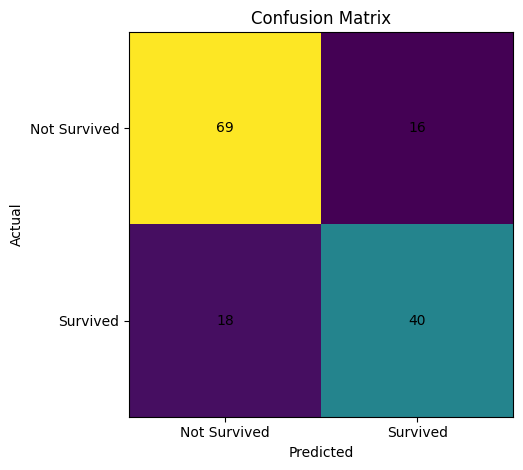

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots()
im = ax.imshow(cm)

# Labels
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# Tick labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Survived", "Survived"])
ax.set_yticklabels(["Not Survived", "Survived"])

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

      Feature  Importance
2         Age    0.268044
3        Fare    0.262797
1    Sex_male    0.246194
0      Pclass    0.098201
4       SibSp    0.052720
5       Parch    0.041515
7  Embarked_S    0.024636
6  Embarked_Q    0.005892


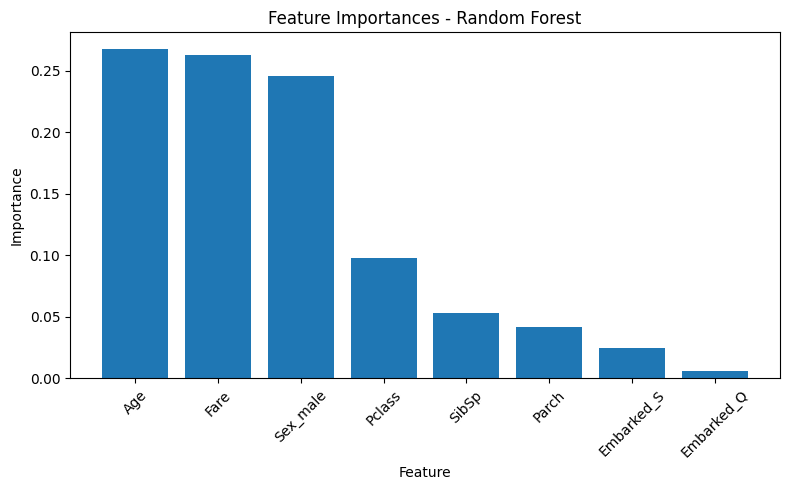

In [23]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

plt.figure(figsize=(8, 5))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importances - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## XGBoost Model

In [24]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)


y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7972027972027972

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83        85
           1       0.75      0.74      0.75        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143


Confusion Matrix:
 [[71 14]
 [15 43]]


      Feature  Importance
1    Sex_male    0.479614
0      Pclass    0.183142
4       SibSp    0.074616
2         Age    0.066466
3        Fare    0.062712
5       Parch    0.052369
7  Embarked_S    0.051234
6  Embarked_Q    0.029848


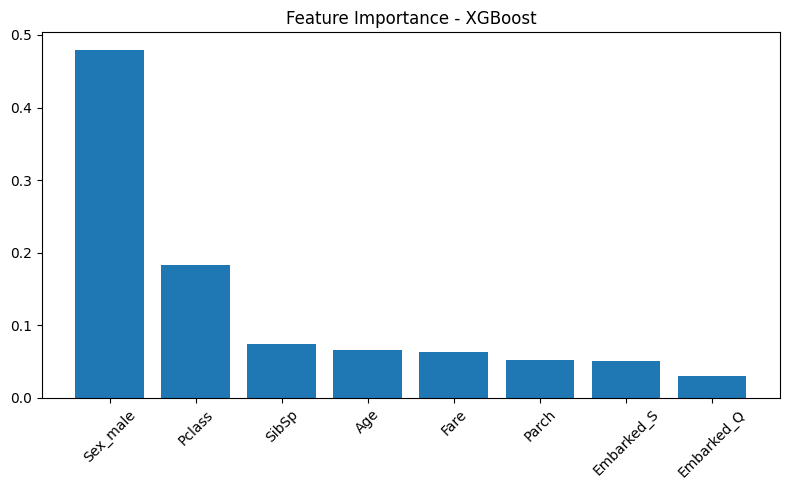

In [25]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

## Logistic Regression Model

In [26]:

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8111888111888111

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84        85
           1       0.77      0.76      0.77        58

    accuracy                           0.81       143
   macro avg       0.80      0.80      0.80       143
weighted avg       0.81      0.81      0.81       143


Confusion Matrix:
 [[72 13]
 [14 44]]


In [27]:
y_prob = log_model.predict_proba(X_test)[:, 1]
print(y_prob[:10])

[0.58669702 0.21858296 0.28268356 0.22706665 0.06671008 0.11230182
 0.09982152 0.03968447 0.21923757 0.87266981]


In [28]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

      Feature  Coefficient
3        Fare     0.000497
5       Parch    -0.003505
2         Age    -0.043923
6  Embarked_Q    -0.306162
4       SibSp    -0.317894
7  Embarked_S    -0.485758
0      Pclass    -1.191274
1    Sex_male    -2.417730


## Model Evaluation

In [29]:
print(df_test.columns)

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='str')


In [30]:
df_test_pred = df_test[features]
test_predictions = log_model.predict(df_test_pred)

submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": test_predictions
})

# Save CSV
submission.to_csv("submission.csv", index=False)

print("CSV file saved as submission.csv")
print(submission.head())
print(submission.info())

CSV file saved as submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None
